# Attention to Grammar

Maybe Q, K, and C are all about grammar. 

After all, word embedding models are very good at picking up grammatical information.

Also, $d_k$ is close to the number of parts of speech.

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns; sns.set()

# TOKENs

In [7]:
TOKEN = pd.read_csv(f"output/austen-melville-TOKEN.csv")\
    .set_index(['chap_num', 'para_num', 'sent_num', 'token_num'])
TOKEN['term_str'] = TOKEN.token_str.str.lower()

In [8]:
TOKEN.head()

token_str    pos   lemma       dep  \
chap_num para_num sent_num token_num                                      
1        0        0        0               Sir  PROPN     Sir  compound   
                           1            Walter  PROPN  Walter  compound   
                           2            Elliot  PROPN  Elliot     nsubj   
                           3                 ,  PUNCT       ,     punct   
                           4                of    ADP      of      prep   

                                     term_str  
chap_num para_num sent_num token_num           
1        0        0        0              sir  
                           1           walter  
                           2           elliot  
                           3                ,  
                           4               of

# Get Embeddings

In [9]:
from gensim.models import word2vec
from gensim.corpora import Dictionary

In [10]:
docs = TOKEN[~TOKEN.pos.str.match('NNPS?')].dropna(subset=['term_str'])\
    .groupby(['chap_num','para_num','sent_num'])\
    .term_str.apply(lambda  x:  x.tolist())\
    .reset_index()['term_str'].tolist()
docs = [doc for doc in docs if len(doc) > 1] # Lose single word docs

In [11]:
vocab = Dictionary(docs)

In [12]:
VOCAB = pd.DataFrame(vocab.items())[1].to_frame('term_str')
VOCAB.index.name = 'term_id'

In [13]:
# VOCAB

In [14]:
# word2vec parameters
w2v_params = dict(
    window = 5,
    vector_size = 50,
    min_count = 1, # THIS LIMITS OUR VOCAB
    workers = 4
)

In [16]:
model = word2vec.Word2Vec(docs, **w2v_params)

In [17]:
EMB = pd.DataFrame(model.wv.vectors, index=VOCAB.term_str)

# GloVe

In [18]:
# GLOVE = pd.read_csv(f"output/GLOVE50.csv").set_index('term_str')

In [19]:
# GLOVE.head()

# Embed Tokens

In [20]:
ALL = TOKEN.join(EMB, on='term_str')

In [21]:
ALL.head()

token_str    pos   lemma       dep  \
chap_num para_num sent_num token_num                                      
1        0        0        0               Sir  PROPN     Sir  compound   
                           1            Walter  PROPN  Walter  compound   
                           2            Elliot  PROPN  Elliot     nsubj   
                           3                 ,  PUNCT       ,     punct   
                           4                of    ADP      of      prep   

                                     term_str         0         1         2  \
chap_num para_num sent_num token_num                                          
1        0        0        0              sir  0.268843 -0.362119 -0.484428   
                           1           walter  0.637963 -0.693769 -0.340087   
                           2           elliot  0.749120 -0.719768 -0.295808   
                           3                ,  0.973964 -0.895731 -0.179394   
                           4               of  0.725749 -0.687655 -0.382191   

                                             3         4  ...        40  \
chap_num para_num sent_num token_num                      ...             
1        0        0        0         -0.443279 -0.632689  ...  0.550776   
                           1         -0.839412 -0.856024  ...  0.463996   
                           2         -1.053049 -0.821188  ...  0.533248   
                           3         -1.413692 -0.815063  ...  0.452799   
                           4         -0.940518 -0.775607  ...  0.595974   

                                            41        42        43        44  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.210418  0.196801 -0.030895  1.561823   
                           1          0.393348  0.530846  0.059549  2.026492   
                           2          0.401110  0.627087  0.082462  2.149654   
                           3          0.509259  0.878229  0.036866  2.410326   
                           4          0.392768  0.525426  0.014910  2.106390   

                                            45        46        47        48  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.182224 -0.437630 -0.694457  0.308379   
                           1          0.180647 -0.444650 -0.715640  0.367104   
                           2          0.252526 -0.471275 -0.786013  0.402353   
                           3          0.307275 -0.486044 -0.937394  0.490159   
                           4          0.271513 -0.480996 -0.755779  0.404822   

                                            49  
chap_num para_num sent_num token_num            
1        0        0        0          0.661595  
                           1          0.799914  
                           2          0.922963  
                           3          1.202857  
                           4          0.880137  

[5 rows x 55 columns]

# Get Q and K Weights

In [53]:
emb_cols = [i for i in range(50)]

In [54]:
# ALL[0]

In [55]:
WQ = ALL.groupby(['pos'])[emb_cols].mean().dropna()

In [64]:
# WQ

In [26]:
WK = ALL.groupby(['dep'])[emb_cols].mean().dropna()

In [65]:
# WK

In [28]:
WQK = WQ.dot(WK.T) #.T.style.background_gradient(axis=None, cmap='Spectral')

# Align with $d_k$

In [ ]:
from sklearn.decomposition import TruncatedSVD

In [90]:
d_k = 10

In [ ]:
svd_engine = TruncatedSVD(n_components=d_k)

In [70]:
WQN = pd.DataFrame(svd_engine.fit_transform(WQ.T))

In [71]:
WKN = pd.DataFrame(svd_engine.fit_transform(WK.T))

In [105]:
WKN

,0,1,2,3,4,5,6,7,8,9
0,2.130544,-0.391386,-0.070616,-0.016207,0.012590,0.014080,-0.014985,0.003901,0.014010,0.005083
1,-2.408530,0.052357,0.182183,-0.046398,-0.011736,0.008883,-0.012477,-0.021539,-0.027395,-0.017957
2,-1.249028,-0.270699,-0.080190,0.072724,-0.006953,-0.013396,0.019310,-0.008284,0.005513,-0.009444
3,-2.996482,0.292894,-0.063734,-0.008867,0.014499,-0.010599,-0.000723,0.010259,-0.021918,0.015932
4,-2.935258,-0.087240,0.243233,0.007431,-0.076316,0.045242,0.034471,-0.024947,0.002538,0.018945
5,-3.614028,0.119055,-0.118379,-0.066093,0.049290,0.009756,0.010545,0.007332,-0.006132,0.009140
6,4.095918,-0.146502,-0.110737,-0.003999,-0.065116,-0.041682,-0.010517,0.000194,-0.014840,0.017089
7,4.239164,0.084640,0.053745,-0.042596,0.077745,0.009425,0.019460,-0.037072,0.004201,0.000288
8,-3.964714,-0.103018,0.018133,0.025033,0.018879,0.012417,0.002752,-0.003587,-0.010003,0.015090
9,-2.846963,0.079265,-0.036322,-0.060224,0.053877,0.053102,0.037775,0.011534,-0.010477,-0.007240


# Test with a Sentence

In [73]:
s = "anne sat in the chair because it was hot".split()

In [74]:
S = EMB.loc[s].reset_index().reset_index().set_index(['index','term_str'])

In [75]:
S

,,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
index,term_str,,,,,,,,,,,,,,,,,,,,,
0,anne,0.512039,-0.561021,-0.321439,-0.735310,-0.621101,-0.845944,0.923399,0.920435,-0.889901,-0.673370,...,0.449768,0.328542,0.412642,0.026591,1.656242,0.153063,-0.335926,-0.578619,0.310249,0.635516
1,sat,0.001675,-0.006256,-0.024733,-0.025154,-0.035799,-0.037455,0.015317,0.022053,-0.041923,-0.011825,...,0.014800,0.003068,0.016601,0.012440,0.038914,0.010050,-0.008300,-0.038875,0.001406,0.038395
2,in,0.577810,-0.694327,-0.493068,-0.791690,-0.959552,-1.076687,1.167287,1.365227,-1.286456,-0.841000,...,0.694606,0.428531,0.411067,0.065930,2.200253,0.168422,-0.581341,-0.736250,0.411771,0.821074
3,the,0.163067,-0.486192,-0.469252,-0.456721,-0.661075,-0.701993,0.737203,1.078014,-0.915788,-0.586648,...,0.705118,0.438860,0.216530,-0.001770,1.673327,0.105953,-0.518501,-0.523513,0.350147,0.532199
4,chair,0.011683,-0.017327,-0.023389,-0.038448,-0.038947,-0.042584,0.032441,0.010961,-0.009233,-0.025339,...,0.016755,0.025762,0.013260,-0.004567,0.036506,0.020086,0.005127,-0.003244,0.000101,0.029677
5,because,0.023653,-0.038571,-0.024064,-0.042900,-0.069583,-0.061564,0.069353,0.111492,-0.073581,-0.027536,...,0.039328,0.044507,0.042676,0.000666,0.166826,0.020466,-0.049380,-0.067386,0.016261,0.071434
6,it,0.392705,-0.404329,-0.211972,-0.590268,-0.460018,-0.683421,0.702480,0.778124,-0.650080,-0.509281,...,0.345315,0.271744,0.347617,0.012070,1.302319,0.113880,-0.261752,-0.493660,0.261447,0.542227
7,was,0.420766,-0.667249,-0.459808,-0.684804,-0.880491,-0.862120,1.019315,1.172307,-1.140759,-0.704907,...,0.679950,0.445732,0.415305,-0.022449,1.953691,0.153517,-0.508757,-0.719003,0.362950,0.655088
8,hot,-0.004207,-0.007626,0.002093,-0.022266,0.013742,-0.007850,0.016900,-0.005630,0.011650,-0.004723,...,0.019399,0.014551,0.017104,0.013612,-0.006033,-0.006640,-0.004665,0.005690,-0.002765,0.021925


In [101]:
Q = S @ WQN
K = S @ WKN
W = Q @ K.T

In [102]:
W

,index,0,1,2,3,4,5,6,7,8
,term_str,anne,sat,in,the,chair,because,it,was,hot
index,term_str,,,,,,,,,
0,anne,4612.507812,160.754684,6169.159668,4410.462891,130.501099,449.374847,3600.732666,5337.547852,27.482611
1,sat,160.795944,5.604053,215.063263,153.755783,4.549380,15.665676,125.524597,186.072937,0.958025
2,in,6158.888184,214.647522,8237.558594,5889.464844,174.251938,600.037170,4807.873535,7127.232910,36.691227
3,the,4381.420410,152.696854,5860.500977,4190.592773,123.960945,426.880280,3420.241699,5070.815918,26.089993
4,chair,130.715775,4.555709,174.829742,124.988037,3.698342,12.734987,102.042839,151.261887,0.778869
5,because,448.471313,15.629965,599.836975,428.862091,12.688451,43.693127,350.094360,518.987854,2.671607
6,it,3601.693604,125.526039,4817.217773,3443.947998,101.902168,350.896973,2811.647949,4167.850098,21.459589
7,was,5321.852539,185.474518,7118.081543,5089.204102,150.569611,518.490051,4154.429688,6158.704590,31.702314


In [94]:
A = W / np.sqrt(d_k)

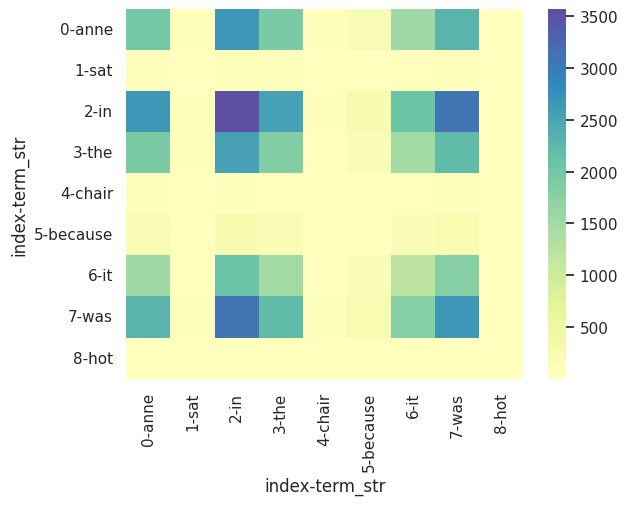

In [98]:
sns.heatmap(A, cmap='Spectral', center=0);